# Phase 2 — Exploratory Data Analysis

This notebook explores the main patterns in the cleaned and feature-engineered
NYC Taxi Fare dataset.

The analysis focuses on three main questions:

1. How does trip distance relate to taxi fare?
2. How do temporal patterns affect fare and trip demand?
3. How are taxi trips geographically distributed across New York City?

The full feature-engineered dataset contains more than 54 million records.
To avoid excessive memory usage, visualization-heavy analyses use a reproducible
sample, while full-dataset aggregation will be used where exact statistics are required.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# Paths
# -------------------------

DATA_PATH = Path("../data/processed/train_features.csv")

EDA_SAMPLE_PATH = Path(
    "../data/processed/eda_sample_300k.csv"
)

FIGURE_DIR = Path(
    "../reports/figures/week2"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------
# Dataset configuration
# -------------------------

TOTAL_ROWS = 54_004_358

CHUNK_SIZE = 500_000
TARGET_SAMPLE_SIZE = 300_000
RANDOM_STATE = 42


# -------------------------
# Plot configuration
# -------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Sampling Strategy

The full dataset is too large to load into memory for interactive exploratory
analysis.

A reproducible sample of approximately 300,000 records is therefore created
using proportional sampling across chunks of the full dataset.

The sample is saved locally so that subsequent notebook runs do not need to
scan the full 6.4 GB dataset again.

Full-dataset aggregation will still be used later for statistics where exact
counts or averages are required.

In [2]:
def sample_large_csv(
    path,
    total_rows,
    target_sample_size=300_000,
    chunksize=500_000,
    random_state=42,
):
    """
    Proportionally sample a large CSV.

    Each row has approximately the same probability of being
    selected regardless of which chunk it belongs to.
    """

    # Slight oversampling ensures that we can obtain
    # exactly target_sample_size rows at the end.
    sample_fraction = min(
        1.0,
        (target_sample_size / total_rows) * 1.02
    )

    sampled_chunks = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            chunksize=chunksize
        )
    ):
        sampled = chunk.sample(
            frac=sample_fraction,
            random_state=random_state + i
        )

        sampled_chunks.append(sampled)

    df_sample = pd.concat(
        sampled_chunks,
        ignore_index=True
    )

    if len(df_sample) >= target_sample_size:
        df_sample = df_sample.sample(
            n=target_sample_size,
            random_state=random_state
        )

    return df_sample.reset_index(drop=True)

In [3]:
if EDA_SAMPLE_PATH.exists():

    print("Loading existing EDA sample...")

    df = pd.read_csv(
        EDA_SAMPLE_PATH
    )

else:

    print("Creating EDA sample from full dataset...")

    df = sample_large_csv(
        DATA_PATH,
        total_rows=TOTAL_ROWS,
        target_sample_size=TARGET_SAMPLE_SIZE,
        chunksize=CHUNK_SIZE,
        random_state=RANDOM_STATE,
    )

    df.to_csv(
        EDA_SAMPLE_PATH,
        index=False
    )

    print(
        f"Sample saved to: {EDA_SAMPLE_PATH}"
    )


print(
    f"EDA sample size: {len(df):,}"
)

print(
    f"Shape: {df.shape}"
)

Loading existing EDA sample...
EDA sample size: 300,000
Shape: (300000, 12)


In [4]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance,pickup_hour,day_of_week,is_weekend
0,2009-01-31 01:09:00.000000167,10.9,2009-01-31 01:09:00 UTC,-73.968408,40.762917,-73.982988,40.721845,1,4.729303,1,5,1
1,2011-12-15 21:22:44.0000002,10.5,2011-12-15 21:22:44 UTC,-73.954191,40.766362,-73.977555,40.729232,1,4.573808,21,3,0
2,2011-02-06 23:40:00.000000107,4.1,2011-02-06 23:40:00 UTC,-74.002688,40.733808,-74.008865,40.725967,2,1.015425,23,6,1
3,2011-07-26 07:51:00.00000097,6.1,2011-07-26 07:51:00 UTC,-73.990537,40.743330,-74.001322,40.756413,2,1.715144,7,1,0
4,2010-03-17 09:29:32.0000005,2.9,2010-03-17 09:29:32 UTC,-73.964496,40.759624,-73.964496,40.759624,3,0.000000,9,2,0


## Sample Validation

Before performing exploratory analysis, the EDA sample is checked for:

- expected feature columns;
- missing values;
- valid temporal feature ranges;
- fare and distance distributions;
- consistency with the earlier development sample.

In [5]:
analysis_columns = [
    "fare_amount",
    "trip_distance",
    "pickup_hour",
    "day_of_week",
    "is_weekend",
    "passenger_count",
]

df[analysis_columns].describe()

,fare_amount,trip_distance,pickup_hour,day_of_week,is_weekend,passenger_count
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,11.338593,3.319089,13.504557,3.042420,0.283373,1.689703
std,9.707806,3.580261,6.510910,1.949733,0.450637,1.305426
min,2.500000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,1.253021,9.000000,1.000000,0.000000,1.000000
50%,8.500000,2.151307,14.000000,3.000000,0.000000,1.000000
75%,12.500000,3.924540,19.000000,5.000000,1.000000,2.000000
max,900.000000,38.660372,23.000000,6.000000,1.000000,6.000000


In [6]:
print("=== Missing Values ===")

print(
    df[
        [
            "fare_amount",
            "trip_distance",
            "pickup_hour",
            "day_of_week",
            "is_weekend",
        ]
    ]
    .isna()
    .sum()
)

=== Missing Values ===
fare_amount      0
trip_distance    0
pickup_hour      0
day_of_week      0
is_weekend       0
dtype: int64


In [7]:
print("Fare quantiles:")

print(
    df["fare_amount"].quantile(
        [
            0,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            1.00,
        ]
    )
)


print("\nDistance quantiles:")

print(
    df["trip_distance"].quantile(
        [
            0,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            1.00,
        ]
    )
)

Fare quantiles:
0.00      2.50
0.25      6.00
0.50      8.50
0.75     12.50
0.95     30.33
0.99     53.00
1.00    900.00
Name: fare_amount, dtype: float64

Distance quantiles:
0.00     0.000000
0.25     1.253021
0.50     2.151307
0.75     3.924540
0.95    10.030908
0.99    20.326212
1.00    38.660372
Name: trip_distance, dtype: float64


## Trip Distance and Fare Amount

The first major analysis examines the relationship between trip distance
and taxi fare.

Trip distance is calculated using the Haversine distance between pickup
and drop-off coordinates. Therefore, it represents straight-line geographic
distance rather than the actual road distance travelled by the taxi.

Both Pearson and Spearman correlations are considered because fare and
distance contain skewed distributions and extreme values.

In [8]:
pearson_corr = (
    df[
        [
            "fare_amount",
            "trip_distance",
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)


spearman_corr = (
    df[
        [
            "fare_amount",
            "trip_distance",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)


print(
    f"Pearson correlation:  {pearson_corr:.4f}"
)

print(
    f"Spearman correlation: {spearman_corr:.4f}"
)

Pearson correlation:  0.8535
Spearman correlation: 0.8466


### Key Finding

Trip distance has a strong positive relationship with taxi fare. The Pearson
correlation is 0.8535 and the Spearman correlation is 0.8466, indicating that
the relationship is both strongly linear and consistently monotonic across
the sampled trips.

Most trips are concentrated in the short-distance and lower-fare region,
while longer trips generally correspond to higher fares. However, the
relationship is not perfectly linear, and several fare bands remain visible,
suggesting that additional factors may also influence the final fare.

The Haversine distance used here represents straight-line geographic distance
rather than the actual driven route, so it should be interpreted as a proxy
for trip length.

### Scatter Plot

A conventional scatter plot is first used to inspect the relationship.

Only a subset of the EDA sample is displayed because plotting hundreds of
thousands of individual points creates severe overplotting.

The axis limits are used only for visualization and do not remove observations
from the dataset.

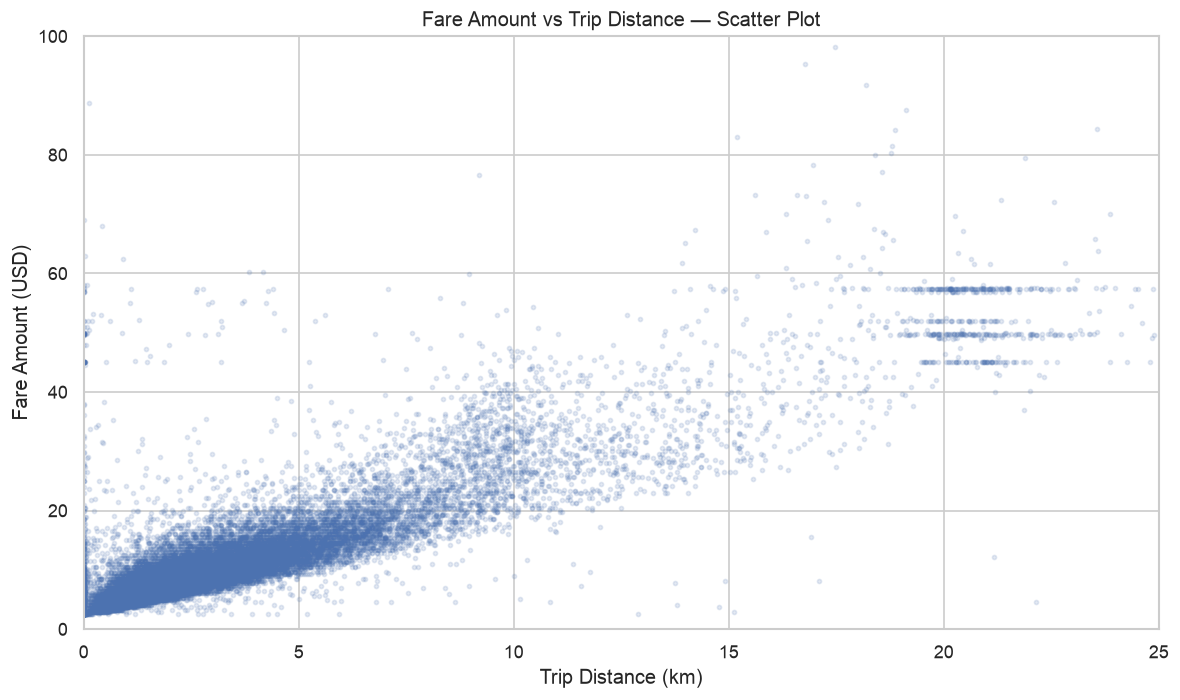

In [9]:
scatter_sample = df.sample(
    n=30_000,
    random_state=RANDOM_STATE
)


plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_sample["trip_distance"],
    scatter_sample["fare_amount"],
    s=6,
    alpha=0.15,
)

plt.xlabel(
    "Trip Distance (km)"
)

plt.ylabel(
    "Fare Amount (USD)"
)

plt.title(
    "Fare Amount vs Trip Distance — Scatter Plot"
)

plt.xlim(
    0,
    25
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()

### Density-based Visualization

Because many taxi trips occupy similar distance–fare combinations, a hexbin
plot provides a clearer representation of the underlying relationship.

Each hexagonal region represents the number of observations within that
distance–fare range. A logarithmic count scale is used because trip density
varies substantially across the plot.

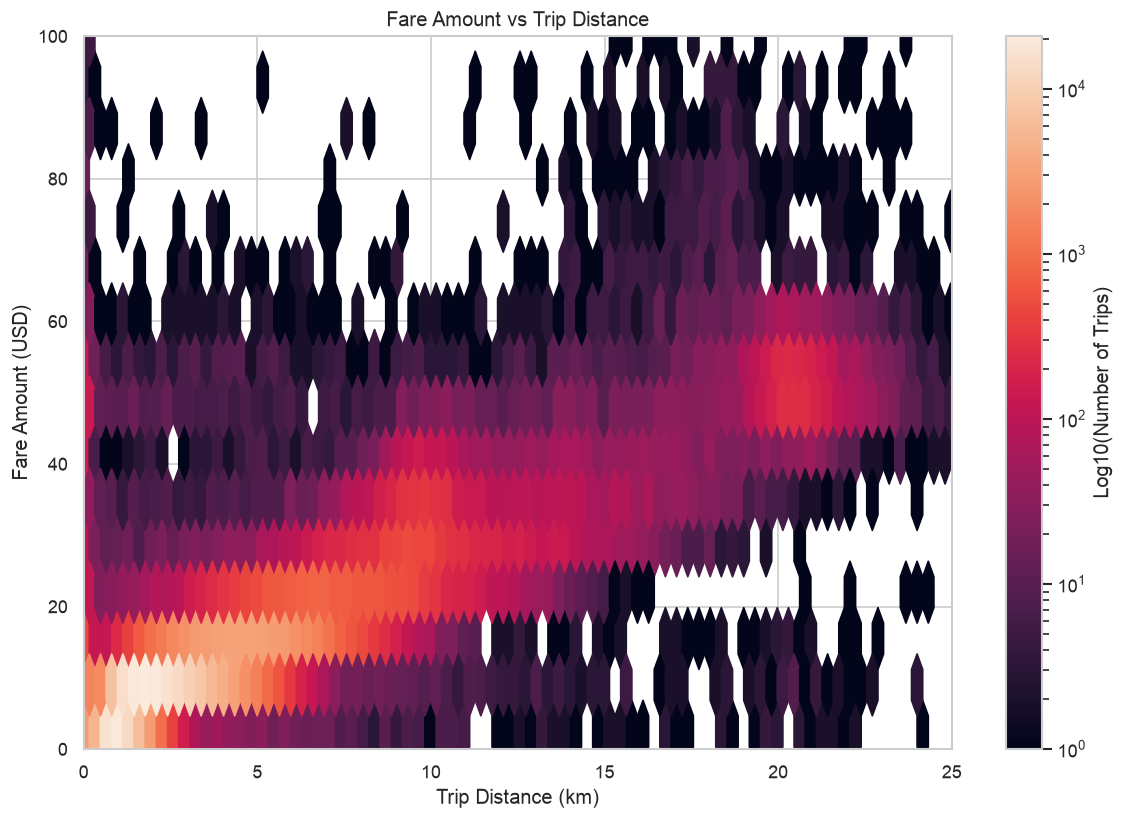

In [10]:
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    df["trip_distance"],
    df["fare_amount"],
    gridsize=120,
    mincnt=1,
    bins="log",
)

plt.colorbar(
    hb,
    label="Log10(Number of Trips)"
)

plt.xlabel(
    "Trip Distance (km)"
)

plt.ylabel(
    "Fare Amount (USD)"
)

plt.title(
    "Fare Amount vs Trip Distance"
)

plt.xlim(
    0,
    25
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fare_vs_distance_hexbin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Zero-distance Trips

A small proportion of records have a calculated trip distance of zero.

These records are retained in the feature-engineered dataset because a zero
Haversine distance does not necessarily imply an invalid taxi transaction.
Possible explanations include identical recorded pickup/drop-off coordinates,
coordinate precision limitations, very short trips, or data-recording issues.

Their influence on the fare-distance relationship is therefore examined
separately rather than automatically removing them.

In [11]:
zero_distance = (
    df["trip_distance"] == 0
)

very_short_distance = (
    df["trip_distance"] <= 0.1
)


print(
    f"Zero-distance trips: "
    f"{zero_distance.sum():,} "
    f"({zero_distance.mean():.2%})"
)

print(
    f"Trips <= 0.1 km: "
    f"{very_short_distance.sum():,} "
    f"({very_short_distance.mean():.2%})"
)


print("\nFare summary for zero-distance trips:")

print(
    df.loc[
        zero_distance,
        "fare_amount"
    ].describe()
)

Zero-distance trips: 3,011 (1.00%)
Trips <= 0.1 km: 4,774 (1.59%)

Fare summary for zero-distance trips:
count    3011.000000
mean       11.028064
std        21.556899
min         2.500000
25%         4.900000
50%         6.900000
75%        10.100000
max       900.000000
Name: fare_amount, dtype: float64


# Temporal Patterns

This section examines how NYC taxi demand and fare patterns vary throughout
the day.

Three metrics are considered for each pickup hour:

- trip volume;
- average fare;
- average trip distance.

Temporal features are extracted directly from the pickup_datetime values
provided in the Kaggle dataset.

Full-dataset aggregation is used here because hourly statistics can be
calculated efficiently without loading the complete dataset into memory.

In [12]:
HOURLY_STATS_PATH = Path(
    "../reports/hourly_stats.csv"
)


def compute_hourly_statistics(
    path,
    chunksize=1_000_000,
):
    """
    Compute exact hourly statistics from the full feature dataset
    using chunk-based aggregation.
    """

    hourly_parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "pickup_hour",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):

        grouped = (
            chunk
            .groupby("pickup_hour")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        hourly_parts.append(grouped)

        print(
            f"Processed chunk {i}"
        )

    hourly = (
        pd.concat(hourly_parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    hourly["avg_fare"] = (
        hourly["fare_sum"]
        / hourly["trip_count"]
    )

    hourly["avg_distance"] = (
        hourly["distance_sum"]
        / hourly["trip_count"]
    )

    return hourly[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

In [13]:
if HOURLY_STATS_PATH.exists():

    print("Loading existing hourly statistics...")

    hourly_stats = pd.read_csv(
        HOURLY_STATS_PATH,
        index_col="pickup_hour",
    )

else:

    print("Computing hourly statistics from full dataset...")

    hourly_stats = compute_hourly_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    hourly_stats.to_csv(
        HOURLY_STATS_PATH
    )

    print(
        f"Saved to: {HOURLY_STATS_PATH}"
    )


hourly_stats

Loading existing hourly statistics...


,trip_count,avg_fare,avg_distance
pickup_hour,,,
0,2137965,11.634956,3.746957
1,1583491,11.364496,3.732829
2,1180812,11.341924,3.787187
3,865189,11.804288,3.990062
4,626831,13.544978,4.635047
5,527879,15.112927,5.177748
6,1107975,12.137950,4.050543
7,1944867,10.959014,3.363392
8,2453287,10.922168,3.021333


In [14]:
print("=== Hourly Statistics ===")
print(hourly_stats.round(3))

print("\n=== Key Hours ===")

busiest_hour = hourly_stats["trip_count"].idxmax()
quietest_hour = hourly_stats["trip_count"].idxmin()

highest_fare_hour = hourly_stats["avg_fare"].idxmax()
lowest_fare_hour = hourly_stats["avg_fare"].idxmin()

longest_trip_hour = hourly_stats["avg_distance"].idxmax()
shortest_trip_hour = hourly_stats["avg_distance"].idxmin()

print(
    f"Busiest hour: {busiest_hour}:00 "
    f"({hourly_stats.loc[busiest_hour, 'trip_count']:,.0f} trips)"
)

print(
    f"Quietest hour: {quietest_hour}:00 "
    f"({hourly_stats.loc[quietest_hour, 'trip_count']:,.0f} trips)"
)

print(
    f"Highest average fare: {highest_fare_hour}:00 "
    f"(${hourly_stats.loc[highest_fare_hour, 'avg_fare']:.2f})"
)

print(
    f"Lowest average fare: {lowest_fare_hour}:00 "
    f"(${hourly_stats.loc[lowest_fare_hour, 'avg_fare']:.2f})"
)

print(
    f"Longest average trip: {longest_trip_hour}:00 "
    f"({hourly_stats.loc[longest_trip_hour, 'avg_distance']:.2f} km)"
)

=== Hourly Statistics ===
             trip_count  avg_fare  avg_distance
pickup_hour                                    
0               2137965    11.635         3.747
1               1583491    11.364         3.733
2               1180812    11.342         3.787
3                865189    11.804         3.990
4                626831    13.545         4.635
5                527879    15.113         5.178
6               1107975    12.138         4.051
7               1944867    10.959         3.363
8               2453287    10.922         3.021
9               2524703    10.869         2.906
10              2436888    10.892         2.951
11              2514558    11.111         2.985
12              2656213    11.099         2.967
13              2639934    11.490         3.126
14              2719807    11.840         3.235
15              2596961    11.935         3.284
16              2228719    11.845         3.339
17              2675843    11.465         3.190
18            

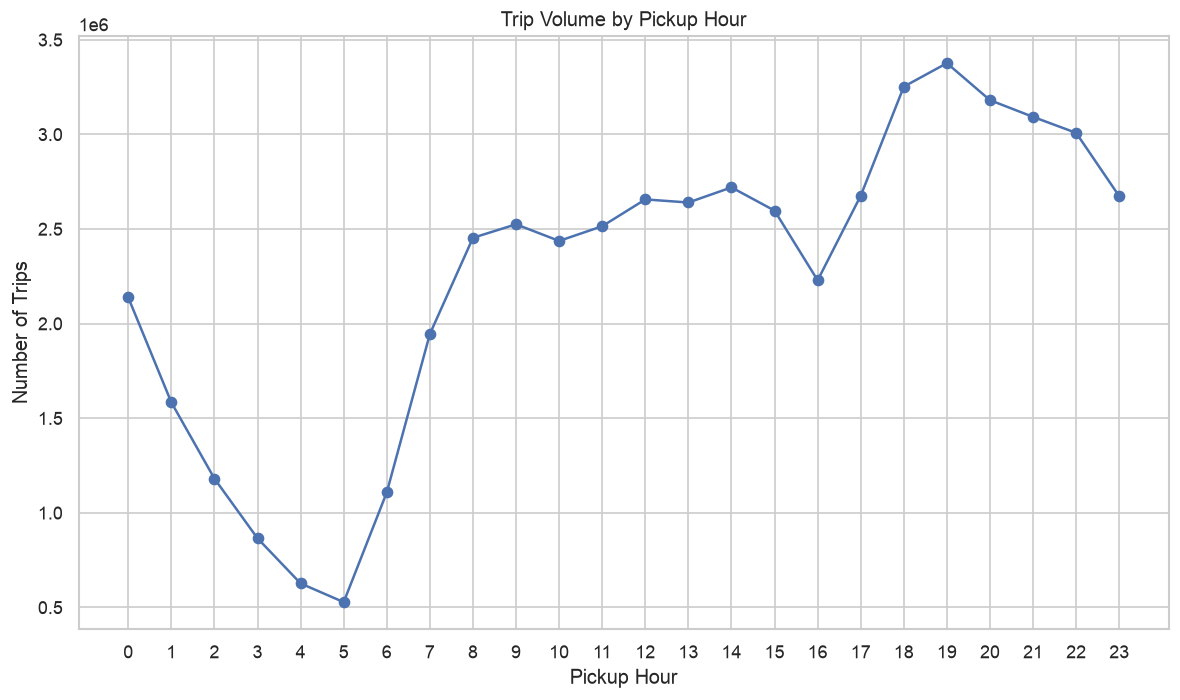

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["trip_count"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Number of Trips"
)

plt.title(
    "Trip Volume by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "trip_volume_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

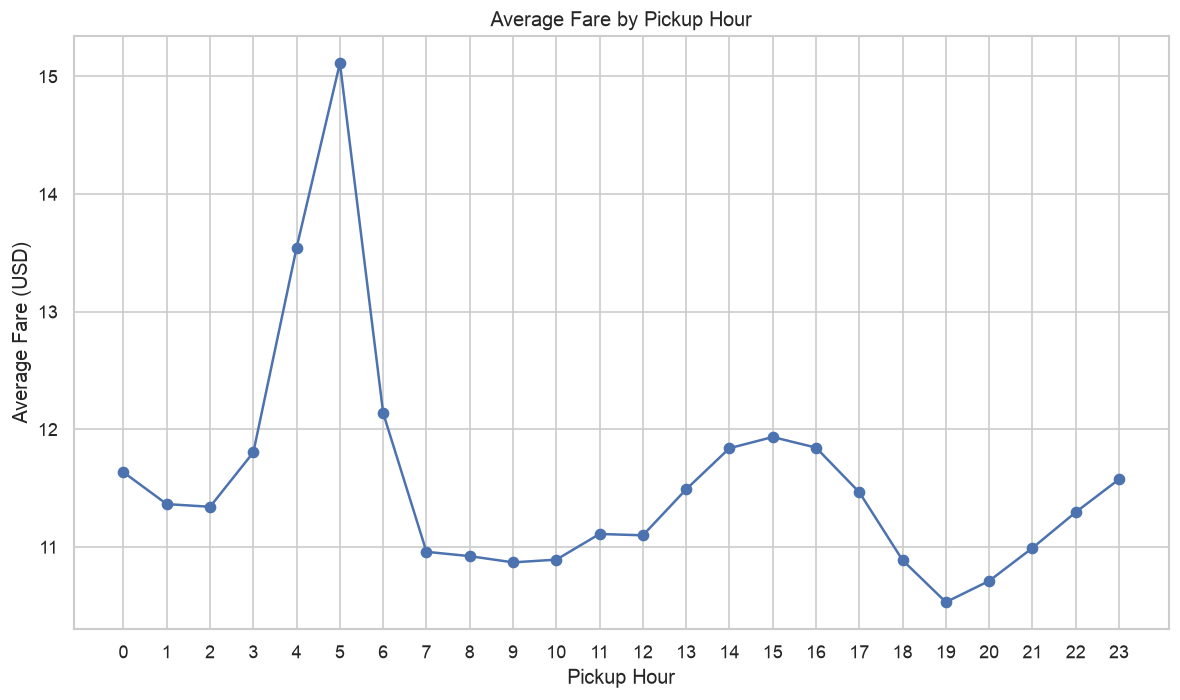

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["avg_fare"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Average Fare (USD)"
)

plt.title(
    "Average Fare by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_fare_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

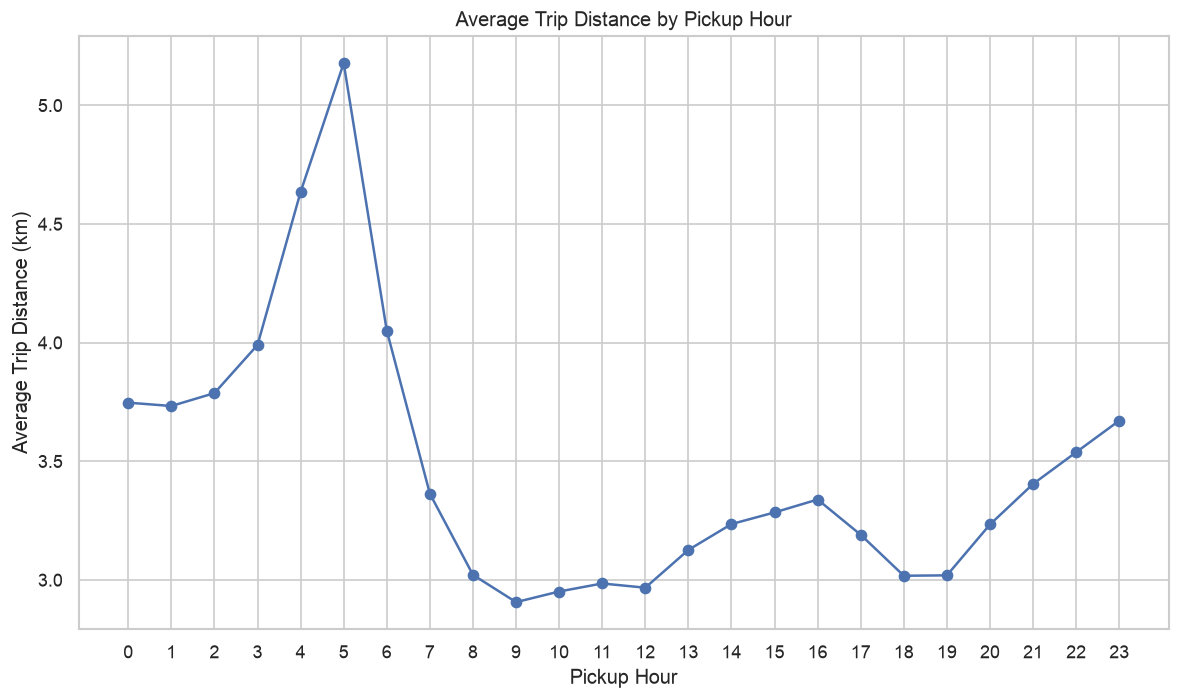

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["avg_distance"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Average Trip Distance (km)"
)

plt.title(
    "Average Trip Distance by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_distance_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

Taxi demand and average fare show distinct hourly patterns.

Trip volume reaches its highest level in the early evening, around 19:00,
while the lowest demand occurs in the early morning around 05:00.

In contrast, the highest average fares occur during the early morning.
This pattern closely follows the average trip distance: trips around 04:00–06:00
are substantially longer than those during most daytime hours.

This suggests that the higher average fares observed in the early morning are
strongly associated with longer trip distances rather than simply higher demand.

Therefore, peak taxi demand and peak average fare occur at different times of day.

## Day-of-Week Patterns

This section examines whether taxi demand, average fare, and average trip
distance vary across the days of the week.

Full-dataset aggregation is used because the resulting statistics contain
only seven groups and can therefore be calculated exactly without loading
the full dataset into memory.

In [ ]:
DAY_OF_WEEK_STATS_PATH = Path(
    "../reports/day_of_week_stats.csv"
)

DAY_NAMES = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}


def compute_day_of_week_statistics(
    path,
    chunksize=1_000_000,
):
    """Compute exact day-of-week statistics in chunks."""

    parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "day_of_week",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):
        grouped = (
            chunk
            .groupby("day_of_week")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        parts.append(grouped)
        print(f"Processed chunk {i}")

    stats = (
        pd.concat(parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    stats["avg_fare"] = (
        stats["fare_sum"]
        / stats["trip_count"]
    )

    stats["avg_distance"] = (
        stats["distance_sum"]
        / stats["trip_count"]
    )

    return stats[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

In [ ]:
if DAY_OF_WEEK_STATS_PATH.exists():

    print("Loading existing day-of-week statistics...")

    day_of_week_stats = pd.read_csv(
        DAY_OF_WEEK_STATS_PATH,
        index_col="day_of_week",
    )

else:

    print("Computing day-of-week statistics from full dataset...")

    day_of_week_stats = compute_day_of_week_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    day_of_week_stats.to_csv(
        DAY_OF_WEEK_STATS_PATH
    )

    print(
        f"Saved to: {DAY_OF_WEEK_STATS_PATH}"
    )


assert (
    day_of_week_stats["trip_count"].sum()
    == TOTAL_ROWS
)

day_of_week_stats.rename(
    index=DAY_NAMES
)

In [ ]:
print("=== Day-of-Week Statistics ===")
print(
    day_of_week_stats
    .rename(index=DAY_NAMES)
    .round(3)
)

print("\n=== Key Days ===")

day_metrics = {
    "Busiest day": ("trip_count", "idxmax"),
    "Quietest day": ("trip_count", "idxmin"),
    "Highest average fare day": ("avg_fare", "idxmax"),
    "Lowest average fare day": ("avg_fare", "idxmin"),
    "Longest average trip day": ("avg_distance", "idxmax"),
    "Shortest average trip day": ("avg_distance", "idxmin"),
}

for label, (column, method) in day_metrics.items():
    day_number = getattr(
        day_of_week_stats[column],
        method,
    )()
    print(
        f"{label}: {DAY_NAMES[day_number]}"
    )

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["trip_count"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Number of Trips"
)

plt.title(
    "Trip Volume by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "trip_volume_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["avg_fare"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Average Fare (USD)"
)

plt.title(
    "Average Fare by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_fare_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["avg_distance"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Average Trip Distance (km)"
)

plt.title(
    "Average Trip Distance by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_distance_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

Trip demand varies across the week, increasing from 6.92 million trips on
Monday to a peak of 8.31 million on Friday. Saturday remains busy, while
demand falls to 7.09 million on Sunday.

Average fares vary within a relatively narrow range of $10.96–$11.61. Sunday
has both the highest average fare and the longest average trip distance
(3.60 km), so the higher Sunday fare coincides with longer trips. However,
the pattern is not consistent across every day, indicating that average trip
distance alone does not explain all day-of-week fare variation.

## Weekday vs Weekend

This comparison examines whether broader temporal patterns differ between
weekdays and weekends.

The analysis considers trip volume, average fare, and average trip distance.
Statistics are calculated from the full feature dataset using the corrected
`is_weekend` field.

In [ ]:
WEEKDAY_WEEKEND_STATS_PATH = Path(
    "../reports/weekday_weekend_stats.csv"
)

WEEKEND_NAMES = {
    0: "Weekday",
    1: "Weekend",
}


def compute_weekday_weekend_statistics(
    path,
    chunksize=1_000_000,
):
    """Compute exact weekday/weekend statistics in chunks."""

    parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "is_weekend",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):
        grouped = (
            chunk
            .groupby("is_weekend")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        parts.append(grouped)
        print(f"Processed chunk {i}")

    stats = (
        pd.concat(parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    stats["avg_fare"] = (
        stats["fare_sum"]
        / stats["trip_count"]
    )

    stats["avg_distance"] = (
        stats["distance_sum"]
        / stats["trip_count"]
    )

    stats = stats[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

    stats.index = stats.index.map(
        WEEKEND_NAMES
    )
    stats.index.name = "group"

    return stats

In [ ]:
if WEEKDAY_WEEKEND_STATS_PATH.exists():

    print("Loading existing weekday/weekend statistics...")

    weekday_weekend_stats = pd.read_csv(
        WEEKDAY_WEEKEND_STATS_PATH,
        index_col="group",
    )

else:

    print("Computing weekday/weekend statistics from full dataset...")

    weekday_weekend_stats = compute_weekday_weekend_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    weekday_weekend_stats.to_csv(
        WEEKDAY_WEEKEND_STATS_PATH
    )

    print(
        f"Saved to: {WEEKDAY_WEEKEND_STATS_PATH}"
    )


assert (
    weekday_weekend_stats["trip_count"].sum()
    == TOTAL_ROWS
)

weekday_weekend_stats.round(3)

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5.5),
)

colors = [
    "#356A8A",
    "#B87545",
]

plot_specs = [
    (
        axes[0],
        "avg_fare",
        "Average Fare",
        "Average Fare (USD)",
        "${:.2f}",
    ),
    (
        axes[1],
        "avg_distance",
        "Average Trip Distance",
        "Average Trip Distance (km)",
        "{:.2f} km",
    ),
]

for ax, column, title, ylabel, value_format in plot_specs:
    bars = ax.bar(
        weekday_weekend_stats.index,
        weekday_weekend_stats[column],
        color=colors,
        width=0.58,
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(
        0,
        weekday_weekend_stats[column].max() * 1.16,
    )

    ax.bar_label(
        bars,
        labels=[
            value_format.format(value)
            for value in weekday_weekend_stats[column]
        ],
        padding=4,
    )

fig.suptitle(
    "Weekday vs Weekend Trip Characteristics",
    fontweight="bold",
)

fig.tight_layout()

plt.savefig(
    FIGURE_DIR / "weekday_vs_weekend.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

The raw totals contain 38.72 million weekday trips and 15.28 million weekend
trips, but these groups cover five and two days of the week respectively.
On a comparable per-day-of-week basis, demand averages approximately 7.74
million trips for weekdays and 7.64 million for weekend days, a difference
of about 1.3%.

Weekend trips have a slightly lower average fare ($11.26 versus $11.32) but a
higher average trip distance (3.42 km versus 3.26 km). Because these metrics
move in opposite directions at this aggregate level, the small fare difference
cannot be explained by average distance alone. This is an association and does
not establish a causal weekend effect.

# Geographic Patterns

This section will investigate the spatial distribution of NYC taxi trips.

The analysis will focus on:

- pickup trip density;
- drop-off trip density;
- major high-density taxi activity areas.

Density-based visualization will be used instead of plotting all individual
trip coordinates.

# Key Findings

Key findings from the exploratory analysis will be summarized here after
the distance, temporal, and geographic analyses are complete.

These findings will later be used to build the Week 2 Executive Summary.